In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
working_directory = "/Users/kemalinecik/git_nosync/sctram"

In [3]:
import sys
sys.path.append(working_directory)

import os
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad
from sctram.generate.real import sc_norman_sciplex_cpa

sc.settings.verbosity = 3

In [4]:
from sctram.infer._paga import PAGAInference
from sctram.infer._dpt import DPTInference

In [5]:
%matplotlib inline
%config InlineBackend.figure_format='retina'
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, 'rb') as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [38]:
dataset_dir = "/Users/kemalinecik/git_nosync/sctram/__temp__/data"
adata_norman = sc_norman_sciplex_cpa(dataset_dir=dataset_dir)
adata_bms = adata_norman[["bms" in i.lower() or "vehicle" in i.lower() for i in adata_norman.obs["drug"]]]

In [39]:
paga_inference = PAGAInference(random_state=42, neighbors_params={"n_neighbors": 90})
adata = ad.AnnData(X=adata_bms.obsm["tardis"].copy(), obs=adata_bms.obs.copy())
paga_inference.infer_trajectory(adata=adata, labels=adata.obs["drug_dose_name"])

2024-10-08 22:55:18,088 - PAGAInference - INFO - Starting PAGAInference trajectory inference.
INFO:PAGAInference:Starting PAGAInference trajectory inference.
2024-10-08 22:55:18,090 - PAGAInference - INFO - No precomputed neighbors found in AnnData. Neighbors will be computed.
INFO:PAGAInference:No precomputed neighbors found in AnnData. Neighbors will be computed.
2024-10-08 22:55:18,091 - PAGAInference - INFO - Computing neighbors.
INFO:PAGAInference:Computing neighbors.


computing neighbors
    using data matrix X directly
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


2024-10-08 22:55:18,230 - PAGAInference - INFO - Performing trajectory calculation.
INFO:PAGAInference:Performing trajectory calculation.


running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)


2024-10-08 22:55:18,451 - PAGAInference - INFO - Trajectory inference completed successfully.
INFO:PAGAInference:Trajectory inference completed successfully.


In [40]:
adata_ = paga_inference.get_result("anndata")
sc.tl.umap(adata_)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:07)


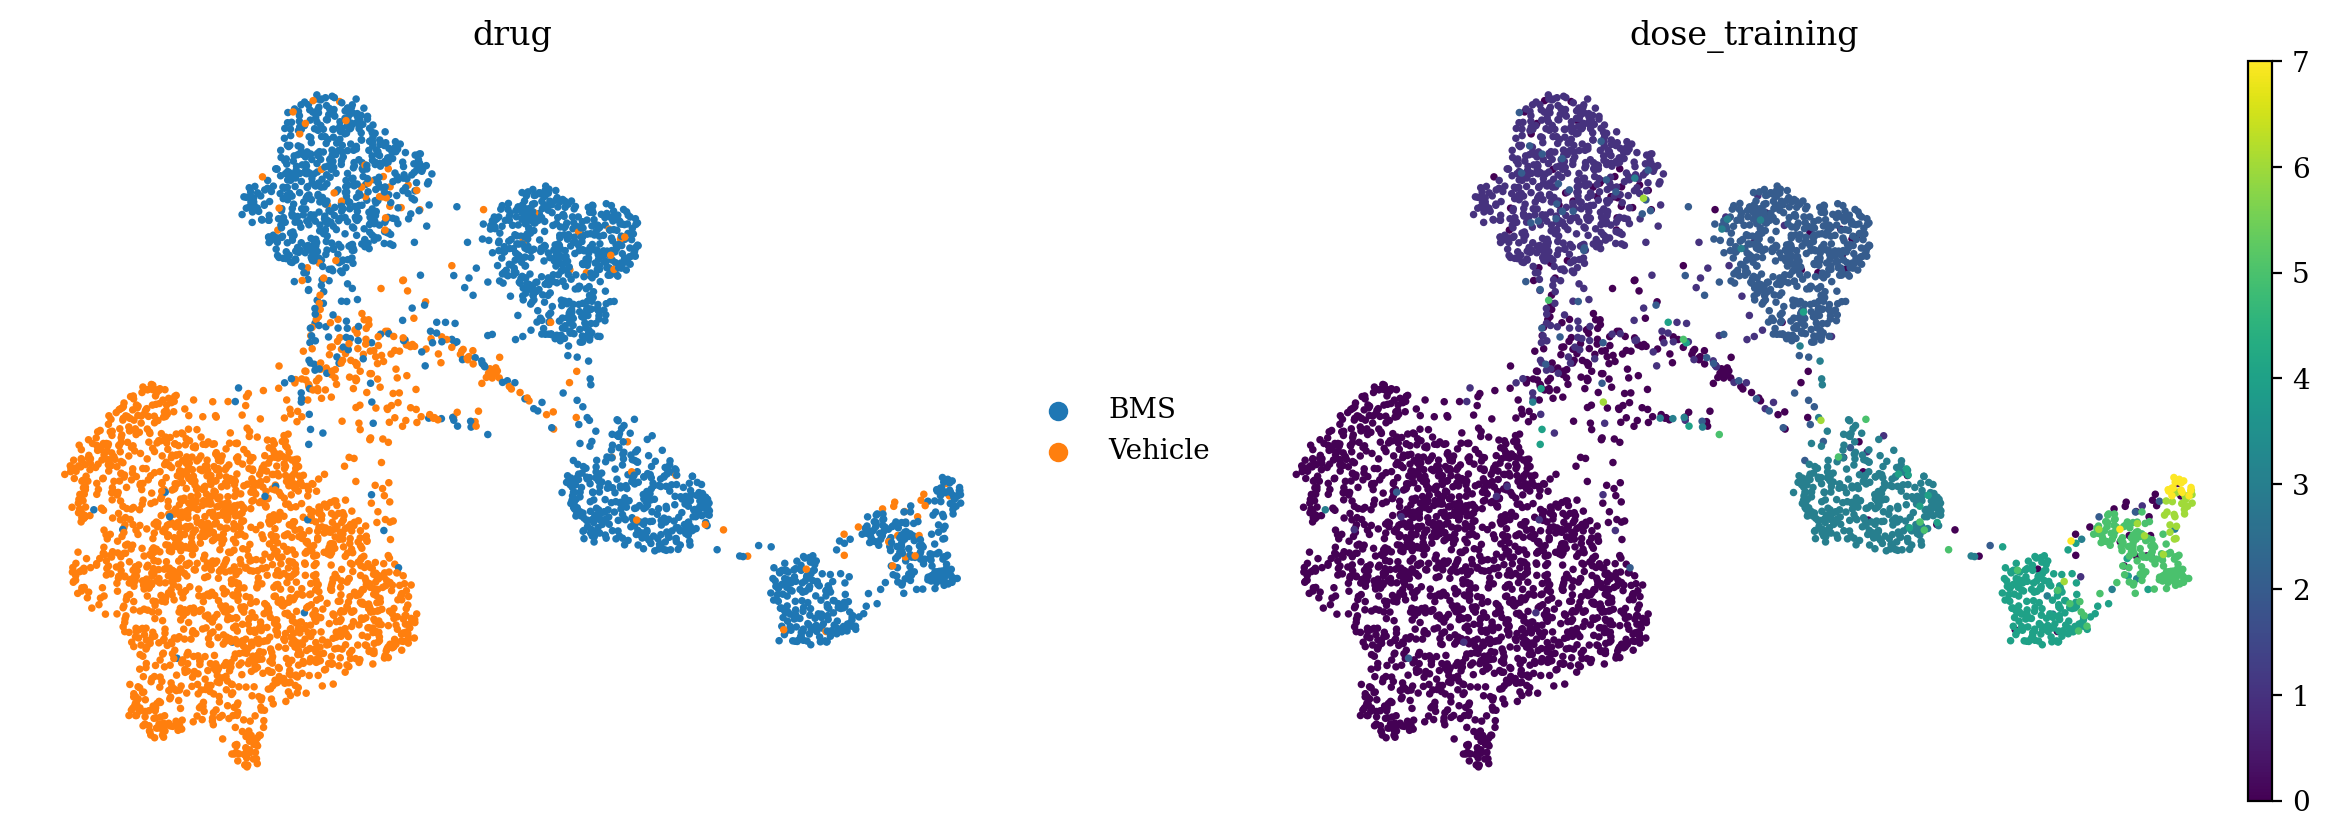

In [41]:
sc.pl.umap(adata_, color=["drug", "dose_training"], frameon=False)

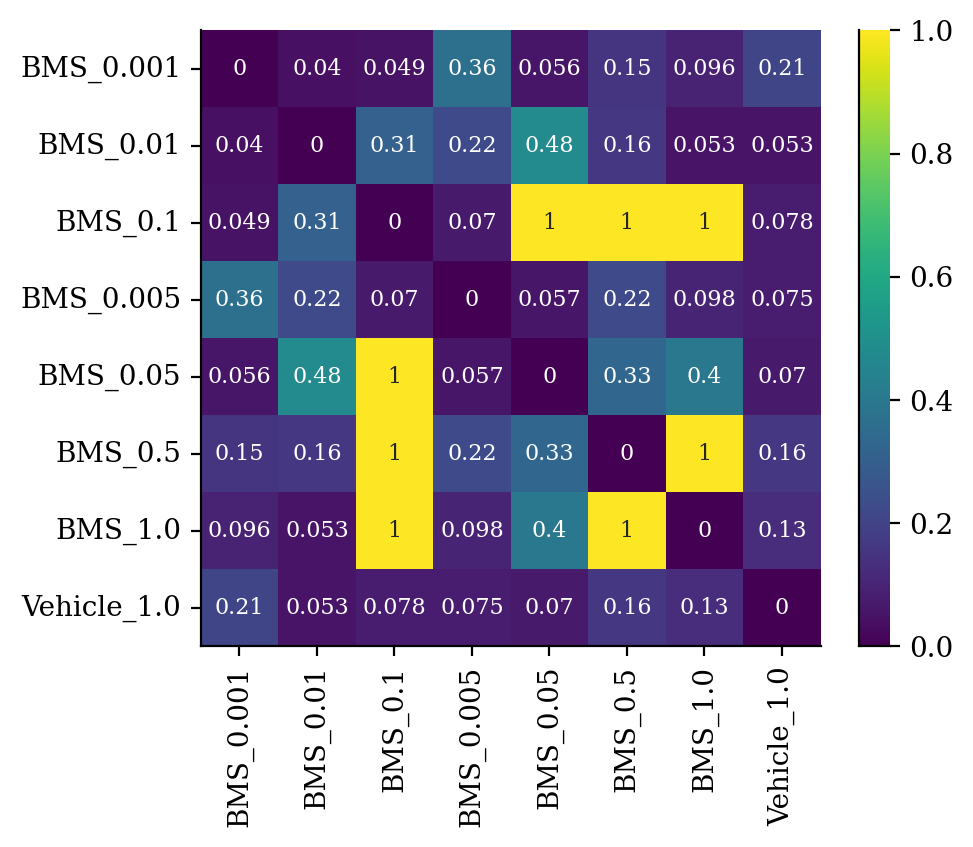

In [42]:
adjacency_matrix = paga_inference.get_result("adjacency")
labels = paga_inference.get_result("labels")

adjacency_matrix = pd.DataFrame(adjacency_matrix, columns=labels, index=labels)
plt.figure(figsize=(5, 4))
sns.heatmap(adjacency_matrix, cmap='viridis', annot=True, annot_kws={"fontsize": 8})
sns.despine()
plt.show()

--> added 'pos', the PAGA positions (adata.uns['paga'])


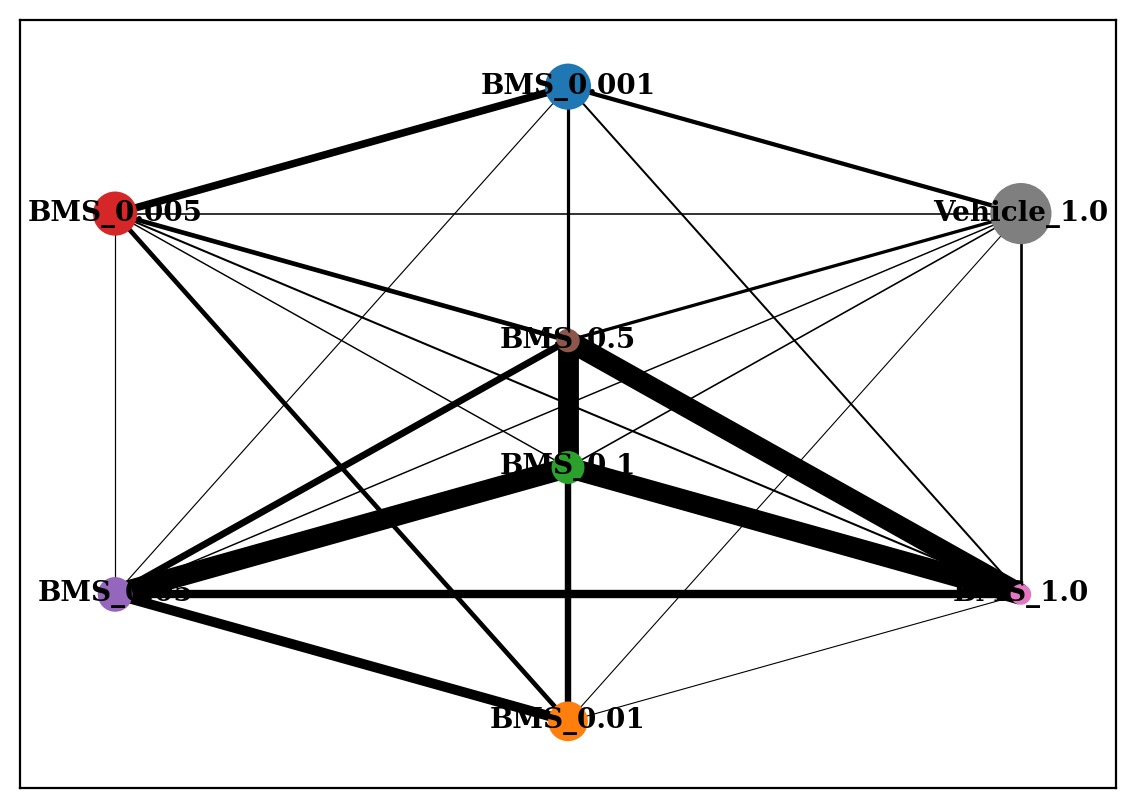

In [43]:
sc.pl.paga(paga_inference.get_result("anndata"), layout="eq_tree")

# DPT

In [49]:
dpt_inference = DPTInference(random_state=42, neighbors_params={"n_neighbors": 90}, 
    iroot={
        "label_key": "labels",
        "label": "Vehicle_1.0",
        "method": "density",
        "outlier_definition_z": None
    },
)
adata = ad.AnnData(X=adata_bms.obsm["tardis"].copy(), obs=adata_bms.obs.copy())
dpt_inference.infer_trajectory(adata=adata, labels=adata.obs["drug_dose_name"])

2024-10-08 22:56:54,501 - DPTInference - INFO - Starting DPTInference trajectory inference.
INFO:DPTInference:Starting DPTInference trajectory inference.
2024-10-08 22:56:54,503 - DPTInference - INFO - No precomputed neighbors found in AnnData. Neighbors will be computed.
INFO:DPTInference:No precomputed neighbors found in AnnData. Neighbors will be computed.
2024-10-08 22:56:54,503 - DPTInference - INFO - Computing neighbors.
INFO:DPTInference:Computing neighbors.


computing neighbors
    using data matrix X directly
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


2024-10-08 22:56:54,634 - DPTInference - INFO - Performing trajectory calculation.
INFO:DPTInference:Performing trajectory calculation.
2024-10-08 22:56:54,634 - DPTInference - INFO - Computing Diffusion Map.
INFO:DPTInference:Computing Diffusion Map.


computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.9957283  0.98897034 0.9752918  0.96000016 0.93977296
     0.9325454  0.9238255  0.90231395 0.8939387  0.89036936 0.88236076
     0.86557806 0.8639325  0.862859  ]
    finished: added
    'X_diffmap', diffmap coordinates (adata.obsm)
    'diffmap_evals', eigenvalues of transition matrix (adata.uns) (0:00:00)


2024-10-08 22:56:54,804 - DPTInference - INFO - No outlier removal applied. Using all 2155 cells in label 'Vehicle_1.0'.
INFO:DPTInference:No outlier removal applied. Using all 2155 cells in label 'Vehicle_1.0'.
2024-10-08 22:56:54,966 - DPTInference - INFO - Suitable radius found: 0.9770 with average neighbors 5.7930, iteration 44.
INFO:DPTInference:Suitable radius found: 0.9770 with average neighbors 5.7930, iteration 44.
2024-10-08 22:56:54,969 - DPTInference - INFO - Root set to cell index 245 with highest density within label 'Vehicle_1.0'.
INFO:DPTInference:Root set to cell index 245 with highest density within label 'Vehicle_1.0'.
2024-10-08 22:56:54,969 - DPTInference - INFO - Performing DPT trajectory calculation.
INFO:DPTInference:Performing DPT trajectory calculation.


computing Diffusion Pseudotime using n_dcs=10
    finished: added
    'dpt_pseudotime', the pseudotime (adata.obs) (0:00:00)


2024-10-08 22:56:54,975 - DPTInference - INFO - Trajectory inference completed successfully.
INFO:DPTInference:Trajectory inference completed successfully.


In [50]:
adata_ = dpt_inference.get_result("anndata")
sc.tl.umap(adata_)

display(adata_.uns["_sctram_densities"].shape)
s = adata_.uns["_sctram_densities"].sum(axis=0)
display(s.shape)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:07)


(44, 2155)

(2155,)

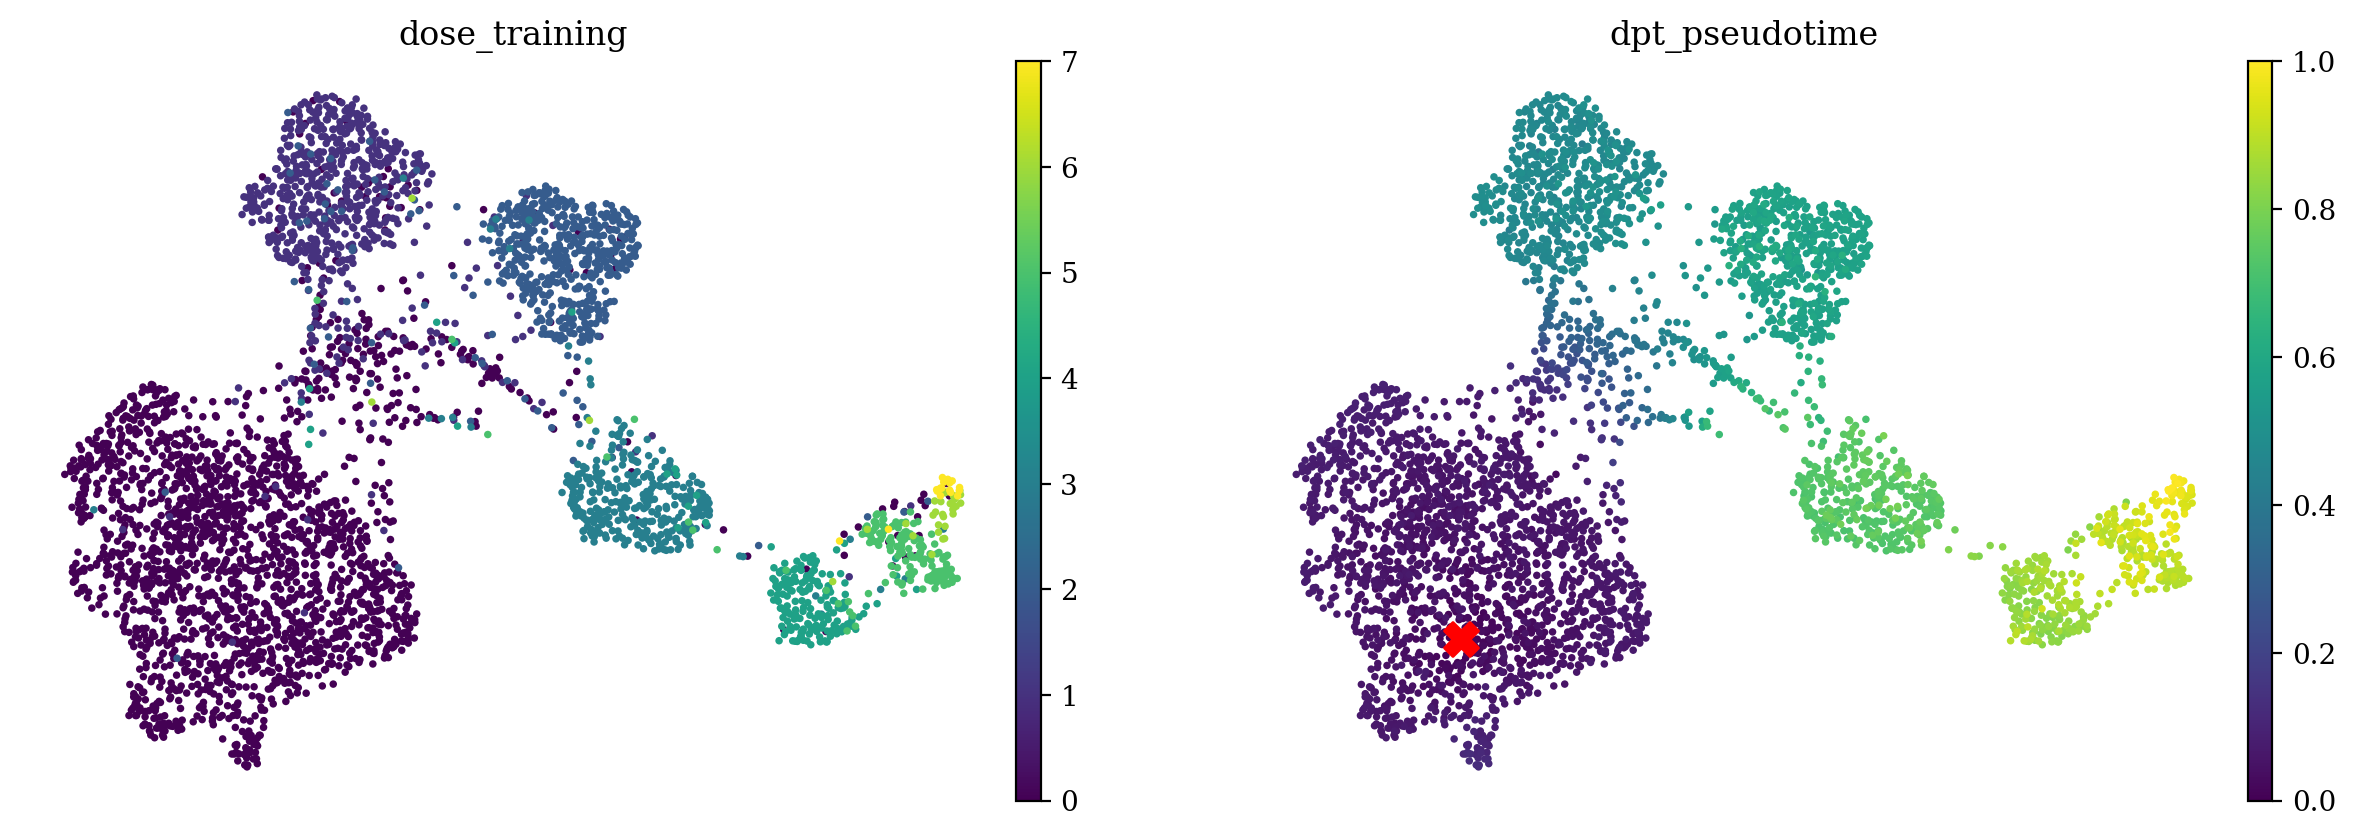

In [51]:
sc.pl.umap(adata_, color=["dose_training", "dpt_pseudotime"], frameon=False, show=False)

# Extract the coordinates of the iroot data point
iroot_index = adata_.uns['iroot']
iroot_coords = adata_.obsm["X_umap"][iroot_index]

# Highlight the iroot data point
plt.scatter(iroot_coords[0], iroot_coords[1], color='red', s=150, marker="X")  # Adjust size with `s`
plt.show()

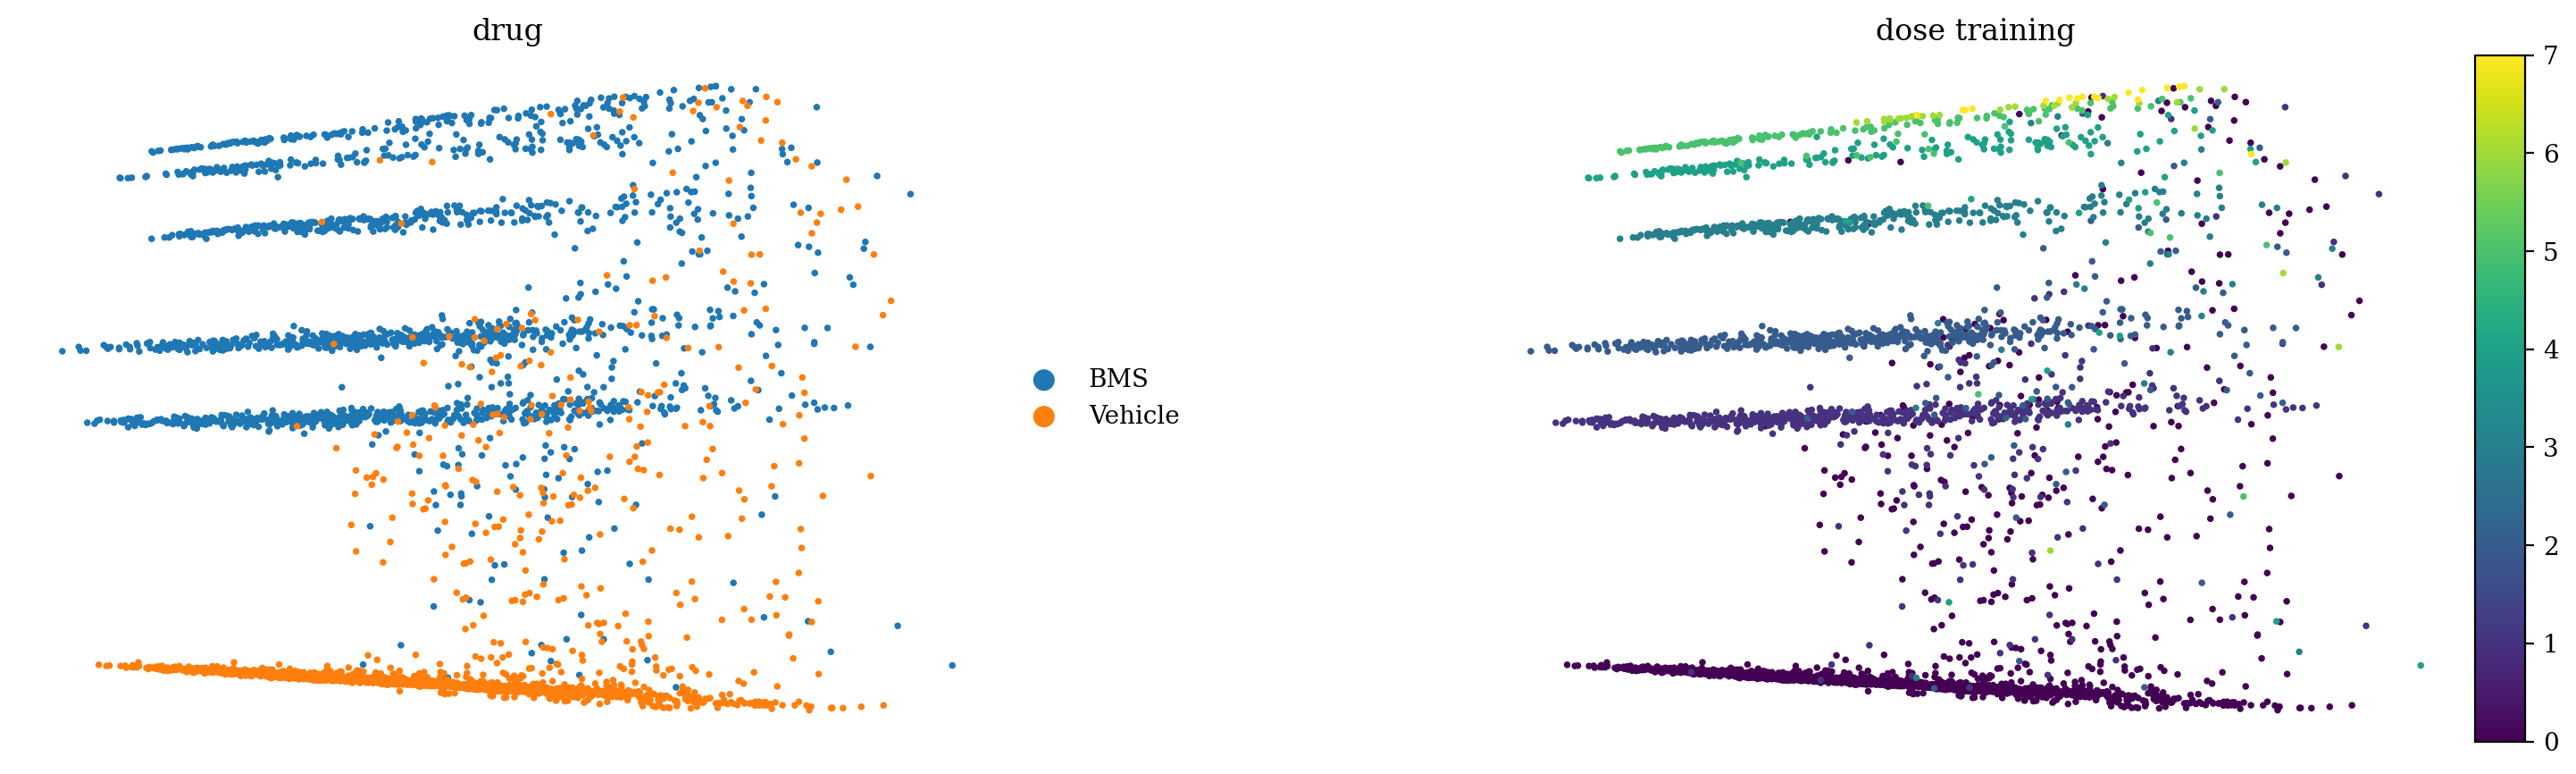

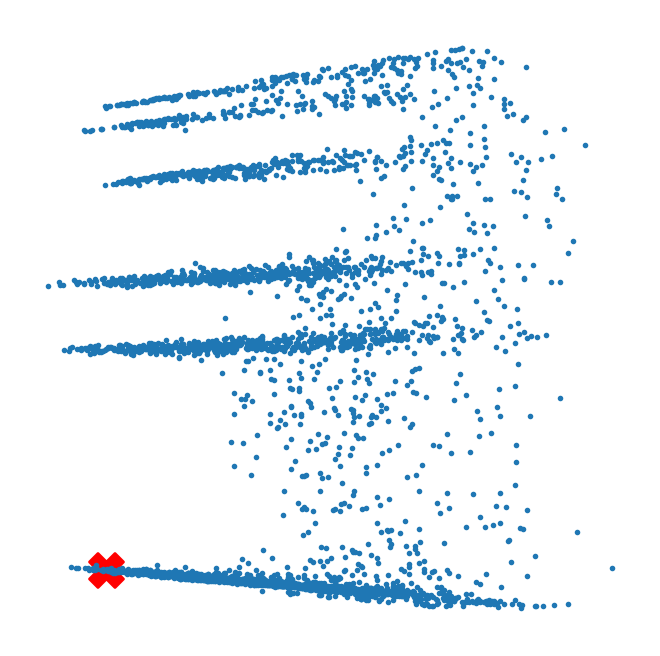

In [52]:
sc.pl.scatter(
    adata_,
    basis="diffmap",
    color=["drug", "dose_training"],
    frameon=False, 
    components=[0,1],
    # show=False
)
# Extract the coordinates of the iroot data point
iroot_index = adata_.uns['iroot']
iroot_coords = adata_.obsm["X_diffmap"][iroot_index]
plt.figure(figsize=(4,4))
plt.scatter(iroot_coords[0], iroot_coords[1], color='red', s=150, marker="X")  # Adjust size with `s`
plt.scatter(adata_.obsm["X_diffmap"][:,0], adata_.obsm["X_diffmap"][:,1], s=1)
plt.axis("off")
plt.show()

In [61]:
dpt_inference = DPTInference(random_state=42, neighbors_params={"n_neighbors": 90}, 
    iroot={
        "label_key": "labels",
        "label": "Vehicle_1.0",
        "method": "centroid",
        "outlier_definition_z": 3
    },
)
adata = ad.AnnData(X=adata_bms.obsm["tardis"].copy(), obs=adata_bms.obs.copy())
dpt_inference.infer_trajectory(adata=adata, labels=adata.obs["drug_dose_name"])

2024-10-08 22:58:37,380 - DPTInference - INFO - Starting DPTInference trajectory inference.
INFO:DPTInference:Starting DPTInference trajectory inference.
2024-10-08 22:58:37,382 - DPTInference - INFO - No precomputed neighbors found in AnnData. Neighbors will be computed.
INFO:DPTInference:No precomputed neighbors found in AnnData. Neighbors will be computed.
2024-10-08 22:58:37,382 - DPTInference - INFO - Computing neighbors.
INFO:DPTInference:Computing neighbors.


computing neighbors
    using data matrix X directly
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


2024-10-08 22:58:37,511 - DPTInference - INFO - Performing trajectory calculation.
INFO:DPTInference:Performing trajectory calculation.
2024-10-08 22:58:37,512 - DPTInference - INFO - Computing Diffusion Map.
INFO:DPTInference:Computing Diffusion Map.


computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.9957283  0.98897034 0.9752918  0.96000016 0.93977296
     0.9325454  0.9238255  0.90231395 0.8939387  0.89036936 0.88236076
     0.86557806 0.8639325  0.862859  ]
    finished: added
    'X_diffmap', diffmap coordinates (adata.obsm)
    'diffmap_evals', eigenvalues of transition matrix (adata.uns) (0:00:00)


2024-10-08 22:58:37,681 - DPTInference - INFO - Outlier removal applied. 1844 out of 2155 cells remain after filtering based on z-score <= 3.
INFO:DPTInference:Outlier removal applied. 1844 out of 2155 cells remain after filtering based on z-score <= 3.
2024-10-08 22:58:37,682 - DPTInference - INFO - Root set to cell index 3888 closest to centroid within label 'Vehicle_1.0'.
INFO:DPTInference:Root set to cell index 3888 closest to centroid within label 'Vehicle_1.0'.
2024-10-08 22:58:37,683 - DPTInference - INFO - Performing DPT trajectory calculation.
INFO:DPTInference:Performing DPT trajectory calculation.


computing Diffusion Pseudotime using n_dcs=10
    finished: added
    'dpt_pseudotime', the pseudotime (adata.obs) (0:00:00)


2024-10-08 22:58:37,689 - DPTInference - INFO - Trajectory inference completed successfully.
INFO:DPTInference:Trajectory inference completed successfully.


In [62]:
adata_ = dpt_inference.get_result("anndata")
sc.tl.umap(adata_)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:07)


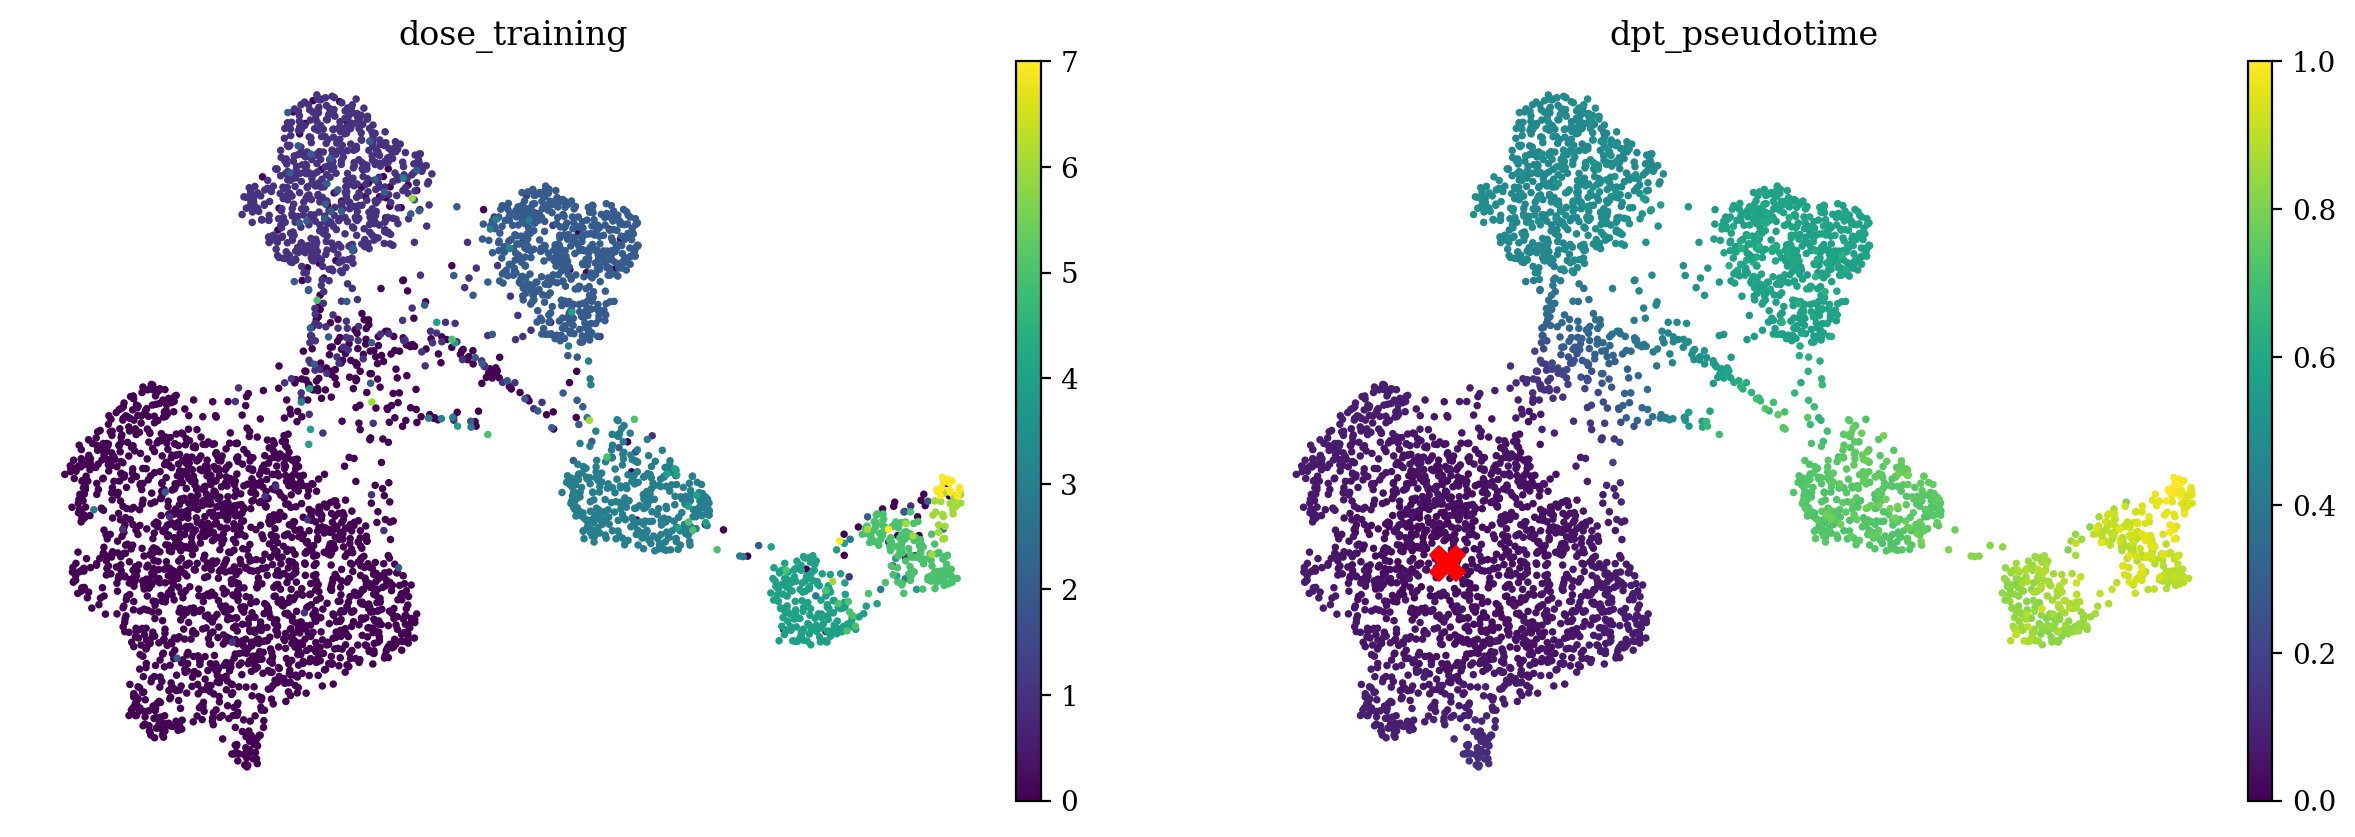

In [63]:
sc.pl.umap(adata_, color=["dose_training", "dpt_pseudotime"], frameon=False, show=False)

# Extract the coordinates of the iroot data point
iroot_index = adata_.uns['iroot']
iroot_coords = adata_.obsm["X_umap"][iroot_index]

# Highlight the iroot data point
plt.scatter(iroot_coords[0], iroot_coords[1], color='red', s=150, marker="X")  # Adjust size with `s`
plt.show()

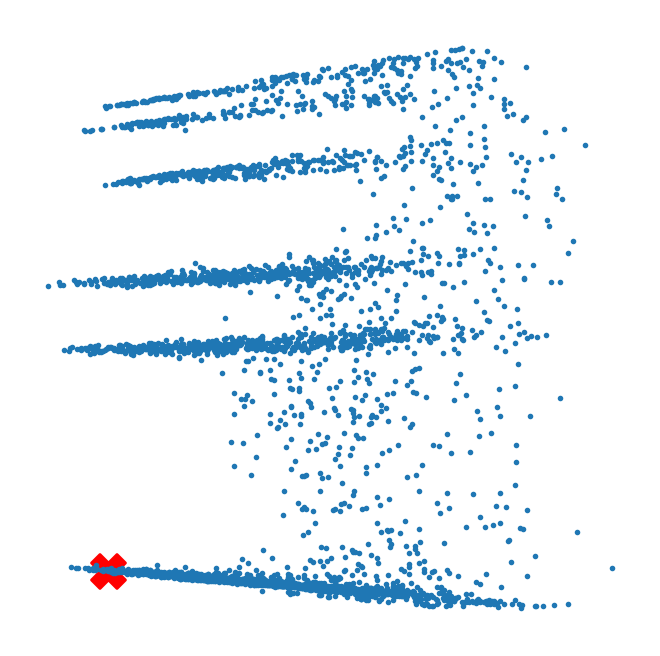

In [64]:
# Extract the coordinates of the iroot data point
iroot_index = adata_.uns['iroot']
iroot_coords = adata_.obsm["X_diffmap"][iroot_index]
plt.figure(figsize=(4,4))
plt.scatter(iroot_coords[0], iroot_coords[1], color='red', s=150, marker="X")  # Adjust size with `s`
plt.scatter(adata_.obsm["X_diffmap"][:,0], adata_.obsm["X_diffmap"][:,1], s=1)
plt.axis("off")
plt.show()

In [73]:
dpt_inference = DPTInference(random_state=42, neighbors_params={"n_neighbors": 90}, 
    iroot={
        "label_key": "labels",
        "label": "Vehicle_1.0",
        "method": "min_diffmap",
        "outlier_definition_z": 3
    },
)
adata = ad.AnnData(X=adata_bms.obsm["tardis"].copy(), obs=adata_bms.obs.copy())
dpt_inference.infer_trajectory(adata=adata, labels=adata.obs["drug_dose_name"])

2024-10-08 23:01:13,824 - DPTInference - INFO - Starting DPTInference trajectory inference.
INFO:DPTInference:Starting DPTInference trajectory inference.
2024-10-08 23:01:13,826 - DPTInference - INFO - No precomputed neighbors found in AnnData. Neighbors will be computed.
INFO:DPTInference:No precomputed neighbors found in AnnData. Neighbors will be computed.
2024-10-08 23:01:13,826 - DPTInference - INFO - Computing neighbors.
INFO:DPTInference:Computing neighbors.


computing neighbors
    using data matrix X directly
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


2024-10-08 23:01:13,966 - DPTInference - INFO - Performing trajectory calculation.
INFO:DPTInference:Performing trajectory calculation.
2024-10-08 23:01:13,967 - DPTInference - INFO - Computing Diffusion Map.
INFO:DPTInference:Computing Diffusion Map.


computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.9957283  0.98897034 0.9752918  0.96000016 0.93977296
     0.9325454  0.9238255  0.90231395 0.8939387  0.89036936 0.88236076
     0.86557806 0.8639325  0.862859  ]
    finished: added
    'X_diffmap', diffmap coordinates (adata.obsm)
    'diffmap_evals', eigenvalues of transition matrix (adata.uns) (0:00:00)


2024-10-08 23:01:14,138 - DPTInference - INFO - Outlier removal applied. 2155 out of 2155 cells remain after filtering based on z-score <= 3.
INFO:DPTInference:Outlier removal applied. 2155 out of 2155 cells remain after filtering based on z-score <= 3.
2024-10-08 23:01:14,139 - DPTInference - INFO - Root set to cell index 2575 based on minimum in DiffMap component 0 within label 'Vehicle_1.0'.
INFO:DPTInference:Root set to cell index 2575 based on minimum in DiffMap component 0 within label 'Vehicle_1.0'.
2024-10-08 23:01:14,140 - DPTInference - INFO - Performing DPT trajectory calculation.
INFO:DPTInference:Performing DPT trajectory calculation.


computing Diffusion Pseudotime using n_dcs=10
    finished: added
    'dpt_pseudotime', the pseudotime (adata.obs) (0:00:00)


2024-10-08 23:01:14,146 - DPTInference - INFO - Trajectory inference completed successfully.
INFO:DPTInference:Trajectory inference completed successfully.


In [74]:
adata_ = dpt_inference.get_result("anndata")
sc.tl.umap(adata_)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:07)


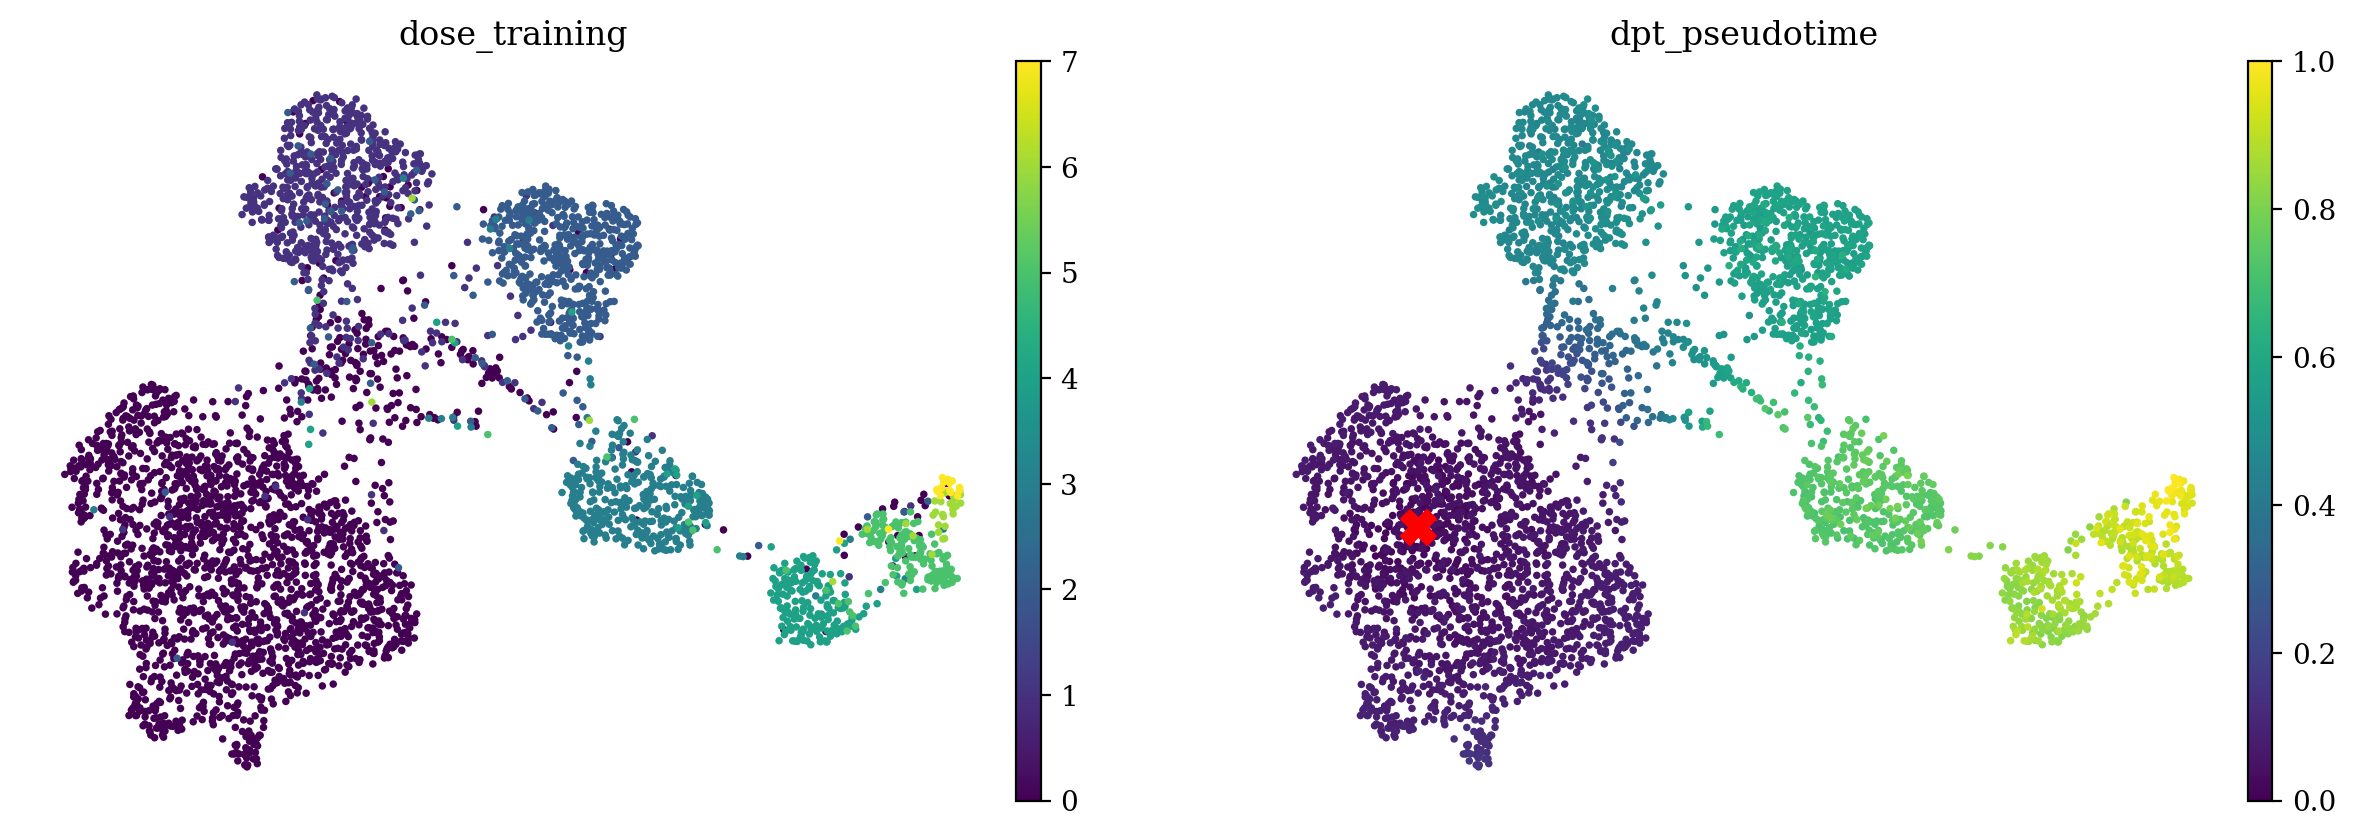

In [75]:
sc.pl.umap(adata_, color=["dose_training", "dpt_pseudotime"], frameon=False, show=False)

# Extract the coordinates of the iroot data point
iroot_index = adata_.uns['iroot']
iroot_coords = adata_.obsm["X_umap"][iroot_index]

# Highlight the iroot data point
plt.scatter(iroot_coords[0], iroot_coords[1], color='red', s=150, marker="X")  # Adjust size with `s`
plt.show()

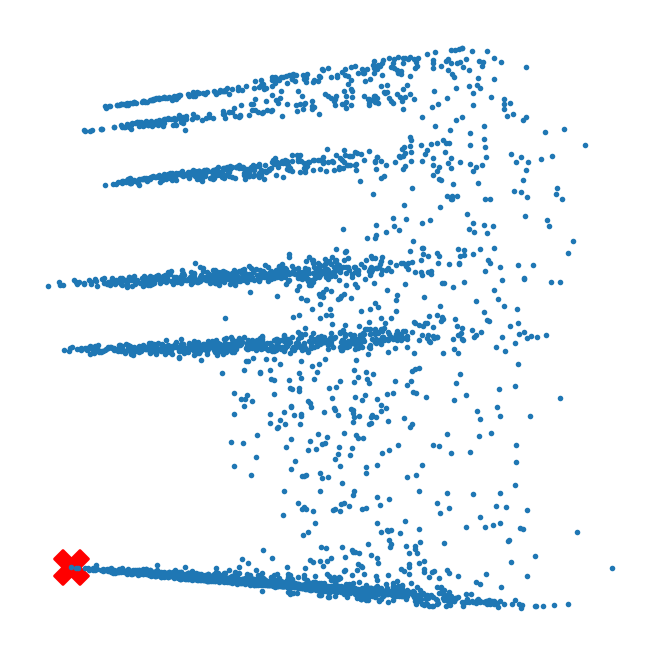

In [76]:
# Extract the coordinates of the iroot data point
iroot_index = adata_.uns['iroot']
iroot_coords = adata_.obsm["X_diffmap"][iroot_index]
plt.figure(figsize=(4,4))
plt.scatter(iroot_coords[0], iroot_coords[1], color='red', s=150, marker="X")  # Adjust size with `s`
plt.scatter(adata_.obsm["X_diffmap"][:,0], adata_.obsm["X_diffmap"][:,1], s=1)
plt.axis("off")
plt.show()